# Olist: Delivery Time Prediction Model

## 1. Data preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import joblib

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

clean = pd.read_parquet("../data/clean/clean.parquet")
print(clean.shape)

(96164, 42)


## 2. Time-based split

In [2]:
clean = clean.sort_values('order_purchase_timestamp').reset_index(drop=True)

split_point = int(len(clean)*0.8)
train = clean.iloc[:split_point]
test = clean.iloc[split_point:]

print("Train size: ", len(train))
print("Test size: ", len(test))
print("Train until: ", train['order_purchase_timestamp'].max())
print("Test from: ", test['order_purchase_timestamp'].min())
print("Test until: ", test['order_purchase_timestamp'].max())


Train size:  76931
Test size:  19233
Train until:  2018-05-27 11:44:23
Test from:  2018-05-27 11:55:26
Test until:  2018-08-29 15:00:37


Split 2018-05-27: train 76,931, test 19,233 (Jun–Aug 2018 — fastest period, drift check). No winter months in test.

## 3. Baselines on test

In [3]:
naive_pred = train['delivery_days'].mean()
mae_naive = (test['delivery_days'] - naive_pred).abs().mean()
mae_olist = test['estimation_error'].abs().mean()

print("Naive prediction: ", naive_pred)
print("Naive MAE: ", mae_naive)
print("Olist MAE: ", mae_olist)


Naive prediction:  12.76100661631852
Naive MAE:  6.187670982060636
Olist MAE:  13.168304476680705


Baselines on test: naive (train mean 12.76) gives MAE 6.19, Olist estimate gives 13.17. Target for the model below 6.19.

## 4. RandomForest

In [4]:
FEATURES = ['purchase_month', 'purchase_day_of_week', 'purchase_year', 'total_price',
            'total_freight', 'quantity_items', 'same_state', 'product_weight_g', 'volume_cm3',
            'customer_state_code', 'seller_state_code', 'product_category_name_code', 'customer_city_code']


print("Missing: ", [c for c in FEATURES if c not in clean.columns])

Missing:  []


In [5]:
TARGET = 'delivery_days'

X_train = train[FEATURES]
Y_train = train[TARGET]
X_test = test[FEATURES]
Y_test = test[TARGET]

print(X_train.shape, X_test.shape)

(76931, 13) (19233, 13)


In [6]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, Y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [7]:
pred = model_rf.predict(X_test)

mae_model_rf = mean_absolute_error(Y_test, pred)
r2_model_rf = r2_score(Y_test, pred)

print("R2 score Random Forest: ", r2_model_rf)
print("MAE score Random Forest: ", mae_model_rf)
print("MAE naive: ", mae_naive)
print("MAE Olist: ", mae_olist)

R2 score Random Forest:  -0.1938134025811884
MAE score Random Forest:  4.752435103818
MAE naive:  6.187670982060636
MAE Olist:  13.168304476680705


## 5. Error analysis

In [8]:
errors_rf = (Y_test - pred).abs()
print(errors_rf.describe().round(2))
print("Errors > 15 days:", (errors_rf > 15).sum())

count    19233.00
mean         4.75
std          3.88
min          0.00
25%          2.02
50%          3.96
75%          6.51
max         48.40
Name: delivery_days, dtype: float64
Errors > 15 days: 373


Median 4.0 days, 75% of orders within 6.5 days. Only 372 orders (under 2%) have errors above 15 days but their squared errors are large enough to push R2 below zero, while MAE stays good (4.76 vs 6.19 naive). The model cannot predict rare long delays.

These delays need a separate model which will predict which orders are at risk of delay.

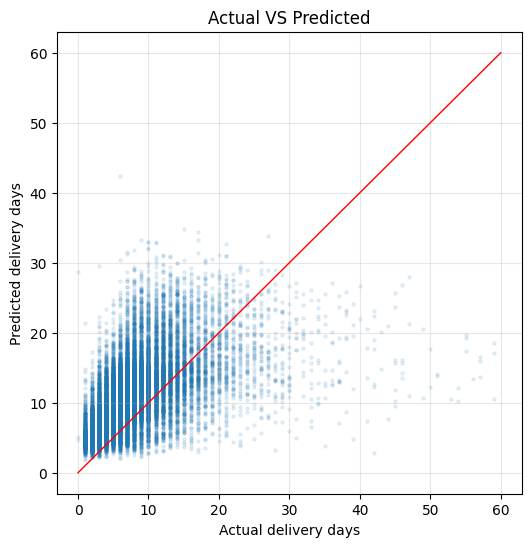

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_test, pred, alpha=0.1, s = 5)
plt.plot([0,60],[0,60], color='Red', linewidth = 1)
plt.xlabel("Actual delivery days")
plt.ylabel("Predicted delivery days")
plt.title("Actual VS Predicted")
plt.show()


Typical deliveries sit on the diagonal. Delays of 30+ days are predicted as 10–20 and model can't see them coming.

## 6. Feature importances

In [10]:
importances = pd.Series(model_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances.round(3))

same_state                    0.166
total_freight                 0.127
total_price                   0.111
volume_cm3                    0.108
product_weight_g              0.099
customer_state_code           0.092
purchase_month                0.076
product_category_name_code    0.067
purchase_day_of_week          0.061
customer_city_code            0.039
seller_state_code             0.024
purchase_year                 0.022
quantity_items                0.008
dtype: float64


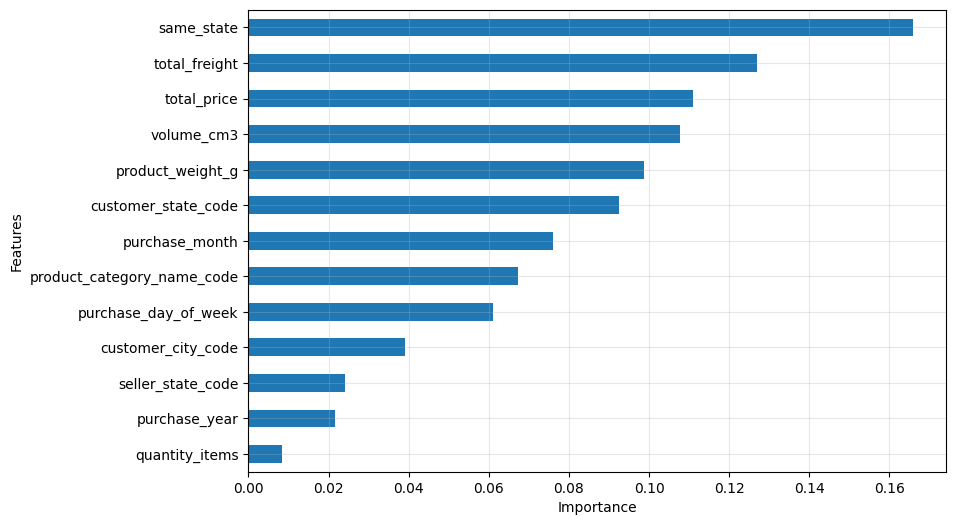

In [11]:
importances.sort_values().plot.barh(figsize=(9, 6))
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

## 7. Feature ablation

Checking whether the four weakest features (by importance) actually contribute to MAE or just add noise. Threshold: 0.02 days.

In [12]:
DROP = ['customer_city_code', 'seller_state_code', 'purchase_year', 'quantity_items']

FEATURES_SLIM = [f for f in FEATURES if f not in DROP]

model_rf_slim = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_slim.fit(train[FEATURES_SLIM], Y_train)
pred_rf_slim = model_rf_slim.predict(test[FEATURES_SLIM])

print("Features: ", len(FEATURES_SLIM))
print("MAE slim: ", round(mean_absolute_error(Y_test, pred_rf_slim), 3))
print("MAE full: ", round(mae_model_rf, 3))

Features:  9
MAE slim:  4.533
MAE full:  4.752


Dropped the four weakest features (customer_city, seller_state, purchase_year, quantity_items).
 MAE improved from 4.752 to 4.533. Weak features were adding noise to the splits.

## 8. HistGradientBoosting

In [13]:
from sklearn.ensemble import HistGradientBoostingRegressor

model_hgb = HistGradientBoostingRegressor(random_state=42)
model_hgb.fit(train[FEATURES_SLIM], Y_train)
pred_hgb = model_hgb.predict(test[FEATURES_SLIM])

print("MAE HGB slim: ", mean_absolute_error(Y_test, pred_hgb))
print("MAE RF slim: ", mean_absolute_error(Y_test, pred_rf_slim))

MAE HGB slim:  4.188257124931075
MAE RF slim:  4.533371004389177


In [14]:
print("R2: ", r2_score(Y_test, pred_hgb))

errors_hgb = round((Y_test - pred_hgb).abs(), 3)
print("Errors > 15: ", (errors_hgb > 15).sum())

R2:  0.08781949290147917
Errors > 15:  201


HistGradientBoosting on the same 9 features: MAE 4.19 vs 4.53 RF slim, R² −0.19 to +0.09, errors over 15 days cut from 372 to 201.

## 9. Distance feature

In [15]:
FEATURES_GEO = FEATURES_SLIM + ['distance_km']

In [16]:
model_hgb_geo = HistGradientBoostingRegressor(random_state=42)
model_hgb_geo.fit(train[FEATURES_GEO], Y_train)
pred_hgb_geo = model_hgb_geo.predict(test[FEATURES_GEO])

print("MAE HGB slim + geo: ", mean_absolute_error(Y_test, pred_hgb_geo))
print("MAE HGB slim: ", mean_absolute_error(Y_test, pred_hgb))

MAE HGB slim + geo:  4.111552232340754
MAE HGB slim:  4.188257124931075


distance_km added: MAE 4.19 to 4.11. State, same_state and freight already carried most of the geographic signal.

## 10. Hyperparameter tuning

In [17]:
param_grid ={
    'max_iter': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [None, 6]
}

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(train[FEATURES_GEO], Y_train)

print("Best params: ", grid.best_params_)
print("Best CV MAE: ", round(-grid.best_score_, 3))

Best params:  {'learning_rate': 0.05, 'max_depth': 6, 'max_iter': 300}
Best CV MAE:  6.155


In [18]:
pred_tuned = grid.best_estimator_.predict(test[FEATURES_GEO])
print("MAE tuned: ", round(mean_absolute_error(Y_test, pred_tuned), 3))
print("MAE default:", round(mean_absolute_error(Y_test, pred_hgb_geo), 3))

MAE tuned:  4.085
MAE default: 4.112


In [19]:
joblib.dump(grid.best_estimator_, "../models/hgb_tuned.joblib")
joblib.dump(FEATURES_GEO, "../models/features.joblib")

['../models/features.joblib']

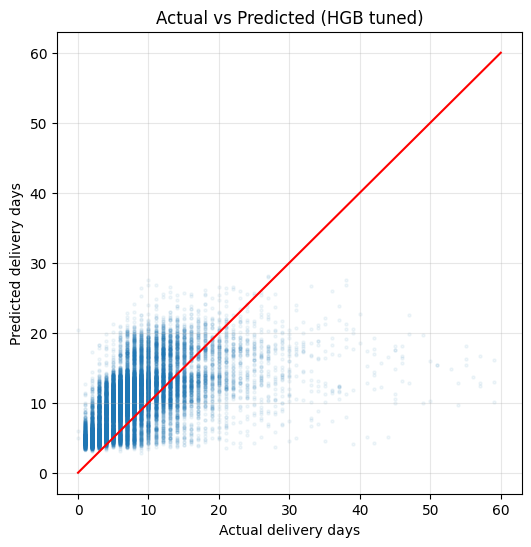

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(Y_test, pred_tuned, alpha=0.06, s=5)
plt.plot([0,60],[0,60], color='red')
plt.xlabel("Actual delivery days")
plt.ylabel("Predicted delivery days")
plt.title("Actual vs Predicted (HGB tuned)")
plt.savefig('../images/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

GridSearch: best params are learning_rate 0.05, max_depth 6, max_iter 300. MAE on test 4.085 vs 4.112 default — a small but real gain, defaults were already close to optimal. Final model.

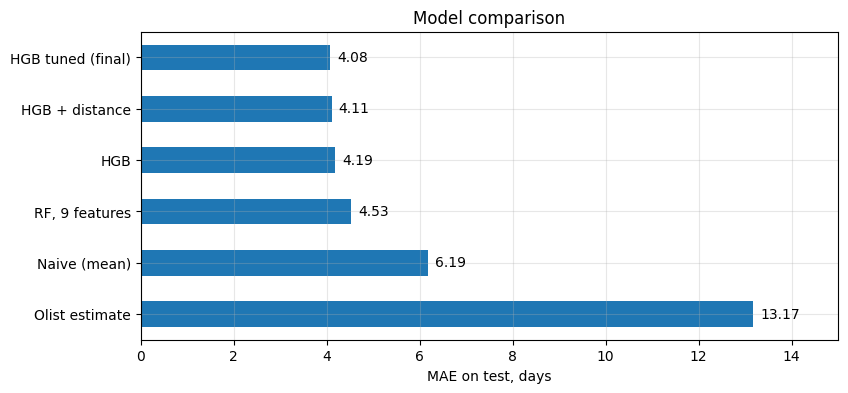

In [21]:
results = pd.Series({
    'Olist estimate': round(mae_olist, 2),
    'Naive (mean)': round(mae_naive, 2),
    'RF, 9 features': round(mean_absolute_error(Y_test, pred_rf_slim), 2),
    'HGB': round(mean_absolute_error(Y_test, pred_hgb), 2),
    'HGB + distance': round(mean_absolute_error(Y_test, pred_hgb_geo), 2),
    'HGB tuned (final)': round(mean_absolute_error(Y_test, pred_tuned), 2),
}).sort_values(ascending=False)

ax = results.plot.barh(figsize=(9, 4))
for i, v in enumerate(results):
    ax.text(v + 0.15, i, str(v), va='center')

plt.xlim(0, 15)
plt.xlabel("MAE on test, days")
plt.title("Model comparison")
plt.savefig('../images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

Final model: HistGradientBoosting with 10 features, tuned with GridSearch. MAE 4.09 on test, compared to 6.19 naive baseline and 13.17 Olist estimate. That is a 34% improvement over naive.

R2 is positive but low. About 200 orders with long delays are still hard to predict from order-time features. This is the reason for the next model — delay-risk classification.